# Task
Load a dataset from seaborn, preprocess it, split it into training, validation, and testing sets using at least three different splitting strategies, train Multiple Linear Regression and at least one other regression model on each split, evaluate the models using RMSE, MSE, MAE, and R², provide a detailed summary of each step, and visualize the performance metrics of all models and splitting strategies in a single plot.

In [ ]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [ ]:
import seaborn as sns
import pandas as pd

dataset_names = sns.get_dataset_names()

print("Number of rows for each seaborn dataset:")
for name in dataset_names:
    try:
        df = sns.load_dataset(name)
        print(f"- {name}: {len(df)} rows")
    except Exception as e:
        print(f"- Could not load dataset {name}: {e}")

Number of rows for each seaborn dataset:
- anagrams: 20 rows
- anscombe: 44 rows
- attention: 60 rows
- brain_networks: 923 rows
- car_crashes: 51 rows
- diamonds: 53940 rows
- dots: 848 rows
- dowjones: 649 rows
- exercise: 90 rows
- flights: 144 rows
- fmri: 1064 rows
- geyser: 272 rows
- glue: 64 rows
- healthexp: 274 rows
- iris: 150 rows
- mpg: 398 rows
- penguins: 344 rows
- planets: 1035 rows
- seaice: 13175 rows
- taxis: 6433 rows
- tips: 244 rows
- titanic: 891 rows


In [ ]:
import seaborn as sns
import pandas as pd

# Load a dataset suitable for regression analysis
df = sns.load_dataset('tips')

# Display the first few rows and information about the dataset
display(df.head())
display(df.info())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


None

In [ ]:
import seaborn as sns
import pandas as pd

# Load a dataset suitable for regression analysis
df = sns.load_dataset('tips')

# Display the first few rows and information about the dataset
display(df.head())
display(df.info())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


None

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_features = df.select_dtypes(include=['category']).columns
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (none in this case)
)

# Apply the preprocessing
df_processed = pd.DataFrame(preprocessor.fit_transform(df), columns=preprocessor.get_feature_names_out())

# Display the first few rows of the processed DataFrame
display(df_processed.head())

,num__total_bill,num__tip,num__size,cat__sex_Female,cat__sex_Male,cat__smoker_No,cat__smoker_Yes,cat__day_Fri,cat__day_Sat,cat__day_Sun,cat__day_Thur,cat__time_Dinner,cat__time_Lunch
0,-0.314711,-1.439947,-0.600193,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-1.063235,-0.969205,0.453383,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.137780,0.363356,0.453383,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.438315,0.225754,-0.600193,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.540745,0.443020,1.506958,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

# Identify target and features
TARGET = 'num__tip'
features = df_processed.drop(columns=[TARGET]).columns

X = df_processed[features]
y = df_processed[TARGET]

# Strategy 1: Single train, validation, test split (60/20/20)
X_train_strategy1, X_temp, y_train_strategy1, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val_strategy1, X_test_strategy1, y_val_strategy1, y_test_strategy1 = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Strategy 1 Shapes:")
print(f"X_train: {X_train_strategy1.shape}, y_train: {y_train_strategy1.shape}")
print(f"X_val: {X_val_strategy1.shape}, y_val: {y_val_strategy1.shape}")
print(f"X_test: {X_test_strategy1.shape}, y_test: {y_test_strategy1.shape}")
print("-" * 30)

# Strategy 2: Time-based split (simulated by sorting by index)
df_sorted = df_processed.sort_index()
X_sorted = df_sorted.drop(columns=[TARGET])
y_sorted = df_sorted[TARGET]

# Split based on index (e.g., first 60% for train, next 20% for val, last 20% for test)
train_size = int(0.6 * len(df_sorted))
val_size = int(0.2 * len(df_sorted))

X_train_strategy2 = X_sorted.iloc[:train_size]
y_train_strategy2 = y_sorted.iloc[:train_size]

X_val_strategy2 = X_sorted.iloc[train_size : train_size + val_size]
y_val_strategy2 = y_sorted.iloc[train_size : train_size + val_size]

X_test_strategy2 = X_sorted.iloc[train_size + val_size :]
y_test_strategy2 = y_sorted.iloc[train_size + val_size :]

print("Strategy 2 Shapes (Simulated Time-Based):")
print(f"X_train: {X_train_strategy2.shape}, y_train: {y_train_strategy2.shape}")
print(f"X_val: {X_val_strategy2.shape}, y_val: {y_val_strategy2.shape}")
print(f"X_test: {X_test_strategy2.shape}, y_test: {y_test_strategy2.shape}")
print("-" * 30)

# Strategy 3: Split by a categorical feature ('day') - Not a true split into train/val/test based on *all* data,
# but demonstrates splitting based on a feature's values.
# For a proper train/val/test, we'll use train_test_split after filtering.
# Let's use 'Sun' for testing, 'Sat' for validation, and the rest for training.

sun_indices = df_processed[df_processed['cat__day_Sun'] == 1].index
sat_indices = df_processed[df_processed['cat__day_Sat'] == 1].index
other_indices = df_processed[(df_processed['cat__day_Sun'] == 0) & (df_processed['cat__day_Sat'] == 0)].index

X_test_strategy3 = X.loc[sun_indices]
y_test_strategy3 = y.loc[sun_indices]

X_val_strategy3 = X.loc[sat_indices]
y_val_strategy3 = y.loc[sat_indices]

X_train_strategy3 = X.loc[other_indices]
y_train_strategy3 = y.loc[other_indices]


print("Strategy 3 Shapes (Split by Day):")
print(f"X_train: {X_train_strategy3.shape}, y_train: {y_train_strategy3.shape}")
print(f"X_val: {X_val_strategy3.shape}, y_val: {y_val_strategy3.shape}")
print(f"X_test: {X_test_strategy3.shape}, y_test: {y_test_strategy3.shape}")
print("-" * 30)

Strategy 1 Shapes:
X_train: (146, 12), y_train: (146,)
X_val: (49, 12), y_val: (49,)
X_test: (49, 12), y_test: (49,)
------------------------------
Strategy 2 Shapes (Simulated Time-Based):
X_train: (146, 12), y_train: (146,)
X_val: (48, 12), y_val: (48,)
X_test: (50, 12), y_test: (50,)
------------------------------
Strategy 3 Shapes (Split by Day):
X_train: (81, 12), y_train: (81,)
X_val: (87, 12), y_val: (87,)
X_test: (76, 12), y_test: (76,)
------------------------------


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge

# Strategy 1
lr_model_strategy1 = LinearRegression()
lr_model_strategy1.fit(X_train_strategy1, y_train_strategy1)

ridge_model_strategy1 = Ridge(alpha=1.0)
ridge_model_strategy1.fit(X_train_strategy1, y_train_strategy1)

# Strategy 2
lr_model_strategy2 = LinearRegression()
lr_model_strategy2.fit(X_train_strategy2, y_train_strategy2)

ridge_model_strategy2 = Ridge(alpha=1.0)
ridge_model_strategy2.fit(X_train_strategy2, y_train_strategy2)

# Strategy 3
lr_model_strategy3 = LinearRegression()
lr_model_strategy3.fit(X_train_strategy3, y_train_strategy3)

ridge_model_strategy3 = Ridge(alpha=1.0)
ridge_model_strategy3.fit(X_train_strategy3, y_train_strategy3)

Ridge()

In [ ]:
# Function to calculate and store metrics
def evaluate_model(model, X_val, y_val, X_test, y_test, strategy_name, model_name):
    results = {}

    # Evaluate on validation set
    y_val_pred = model.predict(X_val)
    results['val_mse'] = mean_squared_error(y_val, y_val_pred)
    results['val_rmse'] = np.sqrt(results['val_mse'])
    results['val_mae'] = mean_absolute_error(y_val, y_val_pred)
    results['val_r2'] = r2_score(y_val, y_val_pred)

    # Evaluate on testing set
    y_test_pred = model.predict(X_test)
    results['test_mse'] = mean_squared_error(y_test, y_test_pred)
    results['test_rmse'] = np.sqrt(results['test_mse'])
    results['test_mae'] = mean_absolute_error(y_test, y_test_pred)
    results['test_r2'] = r2_score(y_test, y_test_pred)

    evaluation_results[f'{strategy_name}_{model_name}'] = results

# Evaluate Strategy 1 models
evaluate_model(lr_model_strategy1, X_val_strategy1, y_val_strategy1, X_test_strategy1, y_test_strategy1, 'strategy1', 'LinearRegression')
evaluate_model(ridge_model_strategy1, X_val_strategy1, y_val_strategy1, X_test_strategy1, y_test_strategy1, 'strategy1', 'Ridge')

# Evaluate Strategy 2 models
evaluate_model(lr_model_strategy2, X_val_strategy2, y_val_strategy2, X_test_strategy2, y_test_strategy2, 'strategy2', 'LinearRegression')
evaluate_model(ridge_model_strategy2, X_val_strategy2, y_val_strategy2, X_test_strategy2, y_test_strategy2, 'strategy2', 'Ridge')

# Evaluate Strategy 3 models
evaluate_model(lr_model_strategy3, X_val_strategy3, y_val_strategy3, X_test_strategy3, y_test_strategy3, 'strategy3', 'LinearRegression')
evaluate_model(ridge_model_strategy3, X_val_strategy3, y_val_strategy3, X_test_strategy3, y_test_strategy3, 'strategy3', 'Ridge')


# Print the results
for model_key, metrics in evaluation_results.items():
    print(f"--- {model_key} ---")
    print(f"Validation MSE: {metrics['val_mse']:.4f}")
    print(f"Validation RMSE: {metrics['val_rmse']:.4f}")
    print(f"Validation MAE: {metrics['val_mae']:.4f}")
    print(f"Validation R²: {metrics['val_r2']:.4f}")
    print(f"Testing MSE: {metrics['test_mse']:.4f}")
    print(f"Testing RMSE: {metrics['test_rmse']:.4f}")
    print(f"Testing MAE: {metrics['test_mae']:.4f}")
    print(f"Testing R²: {metrics['test_r2']:.4f}")
    print("-" * 20)

--- strategy1_LinearRegression ---
Validation MSE: 0.6727
Validation RMSE: 0.8202
Validation MAE: 0.6360
Validation R²: 0.1429
Testing MSE: 0.4859
Testing RMSE: 0.6971
Testing MAE: 0.5404
Testing R²: 0.1905
--------------------
--- strategy1_Ridge ---
Validation MSE: 0.6689
Validation RMSE: 0.8179
Validation MAE: 0.6346
Validation R²: 0.1476
Testing MSE: 0.4829
Testing RMSE: 0.6949
Testing MAE: 0.5391
Testing R²: 0.1956
--------------------
--- strategy2_LinearRegression ---
Validation MSE: 0.9971
Validation RMSE: 0.9985
Validation MAE: 0.7551
Validation R²: 0.2166
Testing MSE: 0.6791
Testing RMSE: 0.8241
Testing MAE: 0.6098
Testing R²: 0.4192
--------------------
--- strategy2_Ridge ---
Validation MSE: 0.9926
Validation RMSE: 0.9963
Validation MAE: 0.7528
Validation R²: 0.2202
Testing MSE: 0.6782
Testing RMSE: 0.8235
Testing MAE: 0.6088
Testing R²: 0.4199
--------------------
--- strategy3_LinearRegression ---
Validation MSE: 0.7262
Validation RMSE: 0.8522
Validation MAE: 0.6157
Valid

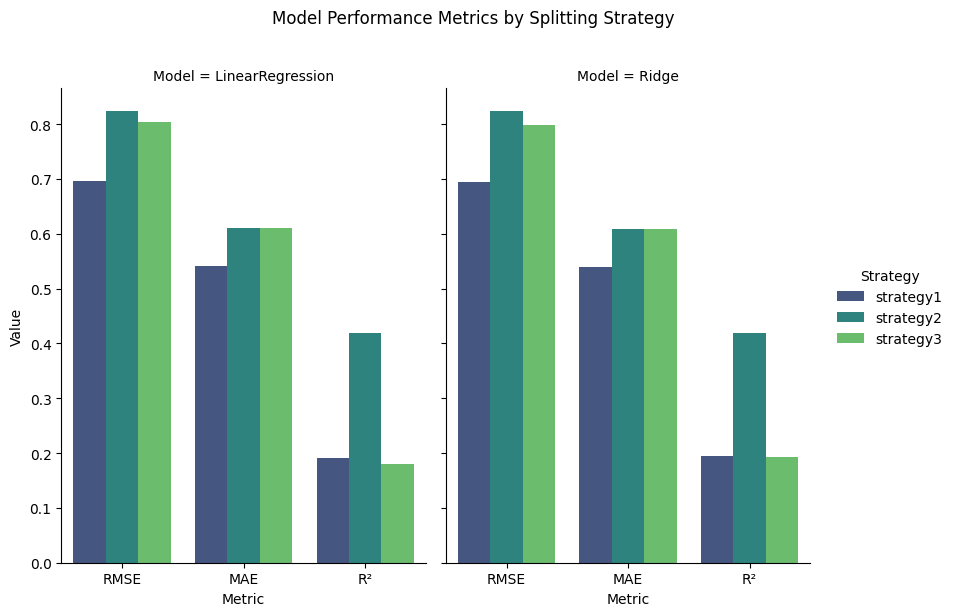

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Prepare data for plotting
plot_data = []
for model_key, metrics in evaluation_results.items():
    strategy, model_name = model_key.split('_')
    plot_data.append({
        'Strategy': strategy,
        'Model': model_name,
        'Metric': 'RMSE',
        'Value': metrics['test_rmse']
    })
    plot_data.append({
        'Strategy': strategy,
        'Model': model_name,
        'Metric': 'MAE',
        'Value': metrics['test_mae']
    })
    plot_data.append({
        'Strategy': strategy,
        'Model': model_name,
        'Metric': 'R²',
        'Value': metrics['test_r2']
    })

plot_df = pd.DataFrame(plot_data)

# Create the plot using catplot
g = sns.catplot(x='Metric', y='Value', hue='Strategy', col='Model', data=plot_df, kind='bar', palette='viridis', height=6, aspect=.7)
g.fig.suptitle('Model Performance Metrics by Splitting Strategy', y=1.02)
g.tight_layout()
plt.show()